In [1]:
import scipy
from scipy import interpolate
import numpy as np

from io import UnsupportedOperation
import pickle as pkl

import matplotlib.pyplot as plt

MAX_SBB = 51

In [2]:
# GenerateEvalData_OREBA()
DATABASE_FILEPATH = "./../Pickle_Databases/ClemCafe.pkl"


with open(DATABASE_FILEPATH,'rb') as fh:
	dataset = pkl.load(fh)
# ClemCafe_Cucumber={README,UniqueID,proc_data_rawAcc,proc_data_noG,handedness, ...
#             ... bites_gt, bites_handedness_gt, means_global_rawAcc, ...
#             ... stddev_global_rawAcc, means_global_noG, stddev_global_noG}

DataFreq=15

bitesIndices = dataset['bites_gt']

# MAX_SBB = 80 # Defined in header
Histogram_CC = np.zeros([MAX_SBB+1])
for i in range(len(bitesIndices)):
    currBiteTimes=bitesIndices[i]/float(DataFreq)
    
    for j in range(1,len(currBiteTimes)):
        sbb=currBiteTimes[j]-currBiteTimes[j-1]
        Histogram_CC[min(MAX_SBB,int(round(sbb)))]+=1
        
    #end j loop
#end i loop

print("Finished making ClemCafe Histogram.")

Finished making ClemCafe Histogram.


In [3]:
# GenerateEvalData_OREBA()
DATABASE_FILEPATH = "./../Pickle_Databases/OREBA.pkl"


with open(DATABASE_FILEPATH,'rb') as fh:
	dataset2 = pkl.load(fh)
# ClemCafe_Cucumber={README,UniqueID,proc_data_rawAcc,proc_data_noG,handedness, ...
#             ... bites_gt, bites_handedness_gt, means_global_rawAcc, ...
#             ... stddev_global_rawAcc, means_global_noG, stddev_global_noG}

DataFreq=64

bitesTimes2 = dataset2['bites_gt']

# MAX_SBB = 80# Defined in header
Histogram_OREBA = np.zeros([MAX_SBB+1])
for i in range(len(bitesTimes2)):
    #grab midpoint of each window
    currBiteTimes2=np.sort((bitesTimes2[i][:,0]+bitesTimes2[i][:,1])/2)
    #currBiteTimes=(bitesTimes[0][:,0] +bitesTimes[0][:,1])/2
    
    for j in range(1,len(currBiteTimes2)):
        sbb=currBiteTimes2[j]-currBiteTimes2[j-1]
        Histogram_OREBA[min(MAX_SBB,int(round(sbb)))]+=1
        
    #end j loop
#end i loop

print("Finished making OREBA Histogram.")

Finished making OREBA Histogram.


In [4]:
# GenerateEvalData_OREBA()
DATABASE_FILEPATH = "./../Pickle_Databases/FIC.pkl"


with open(DATABASE_FILEPATH,'rb') as fh:
	dataset3 = pkl.load(fh)
# ClemCafe_Cucumber={README,UniqueID,proc_data_rawAcc,proc_data_noG,handedness, ...
#             ... bites_gt, bites_handedness_gt, means_global_rawAcc, ...
#             ... stddev_global_rawAcc, means_global_noG, stddev_global_noG}

DataFreq=100

bitesTimes3 = dataset3['bite_gt']

# MAX_SBB = 80 # Defined in header
Histogram_FIC = np.zeros([MAX_SBB+1])
for i in range(len(bitesTimes3)):
    #grab midpoint of each window
    currBiteTimes3=np.sort((bitesTimes3[i][:,0]+bitesTimes3[i][:,1])/2)
    #currBiteTimes=(bitesTimes[0][:,0] +bitesTimes[0][:,1])/2
    
    for j in range(1,len(currBiteTimes3)):
        sbb=currBiteTimes3[j]-currBiteTimes3[j-1]
        Histogram_FIC[min(MAX_SBB,int(round(sbb)))]+=1
        
    #end j loop
#end i loop

print("Finished making FIC Histogram.")

FileNotFoundError: [Errno 2] No such file or directory: './../Pickle_Databases/FIC.pkl'

<BarContainer object of 52 artists>

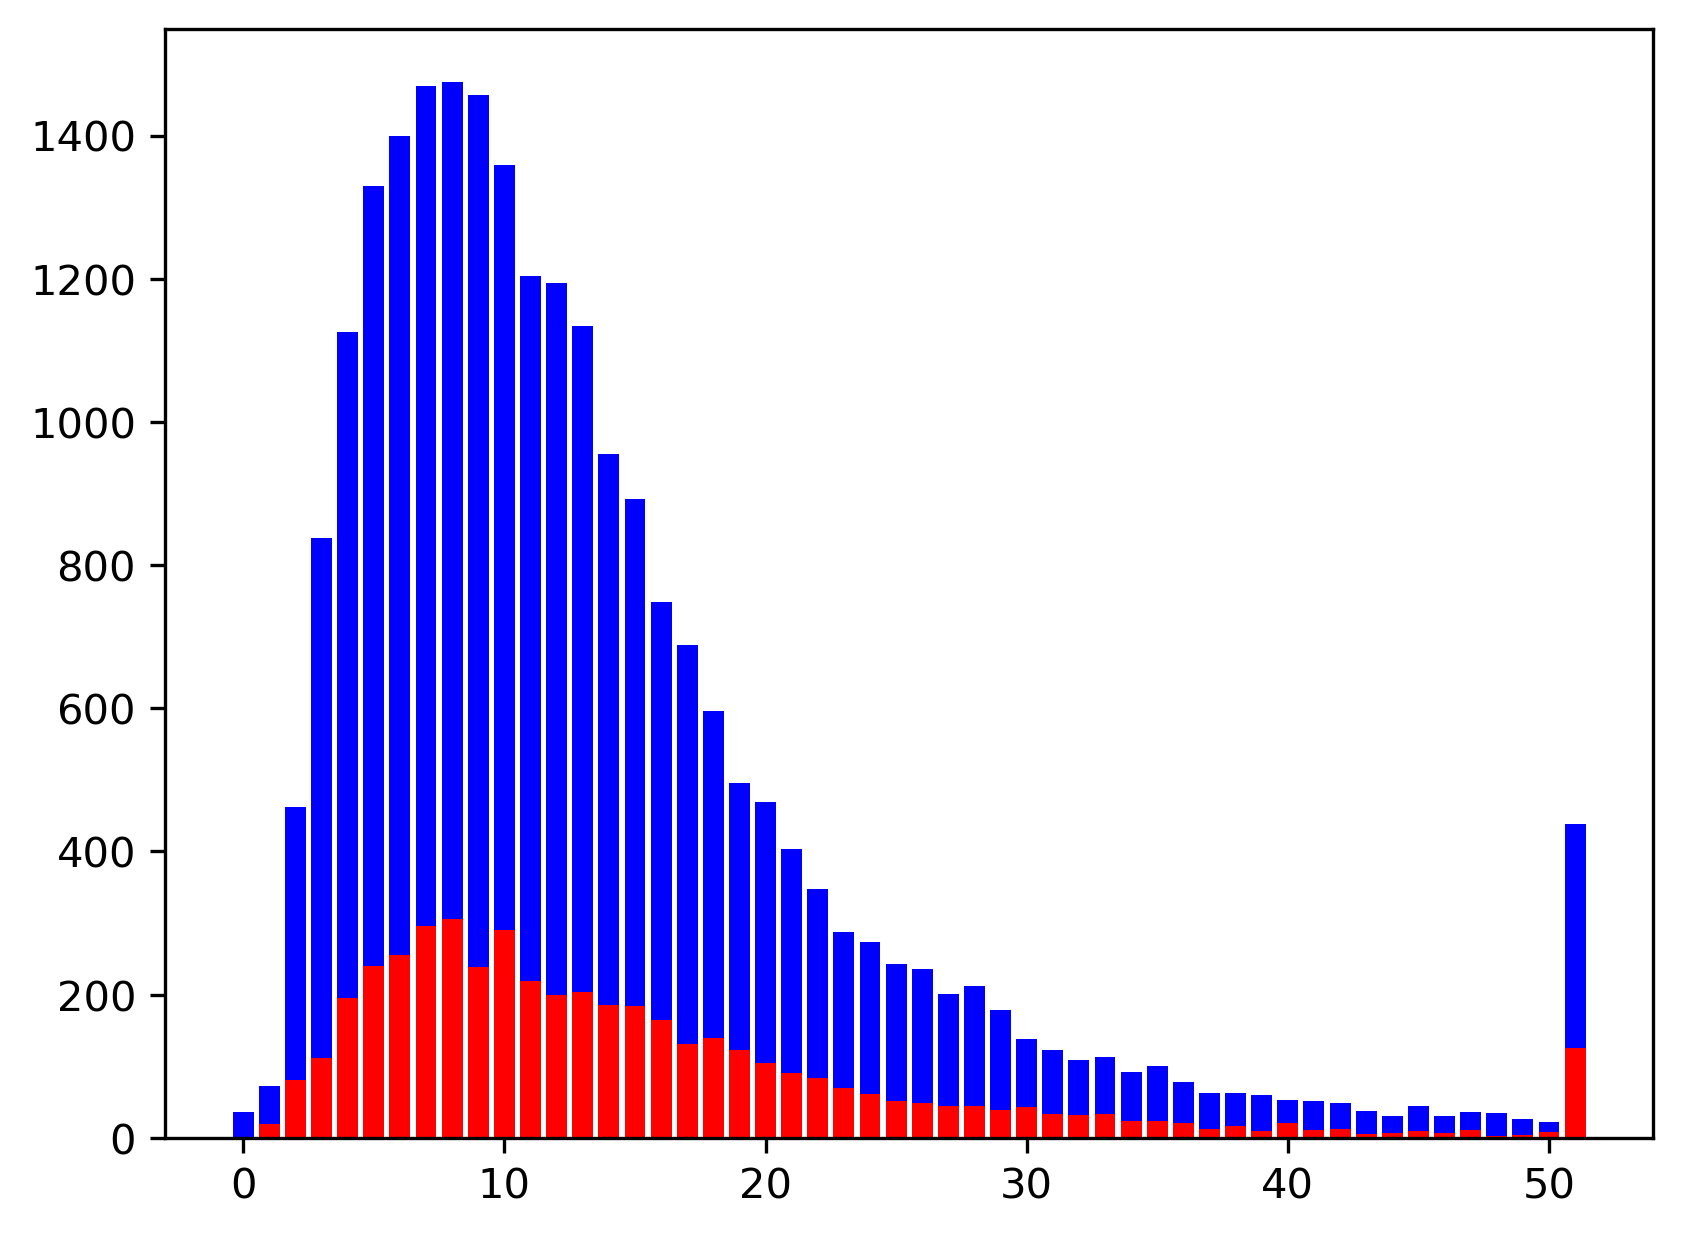

In [5]:
x_range = np.arange(0,MAX_SBB+1)

plt.figure("w",dpi=300)

plt.bar(x_range,Histogram_CC,color='b')
plt.bar(x_range,Histogram_OREBA,color='r')


In [7]:
### CLACULATE THE NUMBER OF BITES PER MEAL FOR EACH DATASET ### 

# for i in range(20):
# 	print("{} {}".format(len(bitesTimes3[i]),len(bitesTimes2[i])))

# print(len(bitesTimes3[0]))
# print(len(bitesTimes2[0]))
# len((currBiteTimes[0]))


sum_ClemCafe = 0
for i in range(len(bitesIndices)):
	sum_ClemCafe+=len(bitesIndices[i])
avg_ClemCafe = sum_ClemCafe/len(bitesIndices)

sum_OREBA = 0
for i in range(len(bitesTimes2)):
	sum_OREBA+=len(bitesTimes2[i])
avg_OREBA = sum_OREBA/len(bitesTimes2)

# sum_FIC = 0
# for i in range(len(bitesTimes3)):
# 	sum_FIC+=len(bitesTimes3[i])
# avg_FIC = sum_FIC/len(bitesTimes3)


print("Average ClemC = ",avg_ClemCafe)
print("Average OREBA = ",avg_OREBA)
# print("Average FIC   = ",avg_FIC)


Average ClemC =  46.496138996138995
Average OREBA =  47.9


Text(0, 0.5, 'Number of samples [#]')

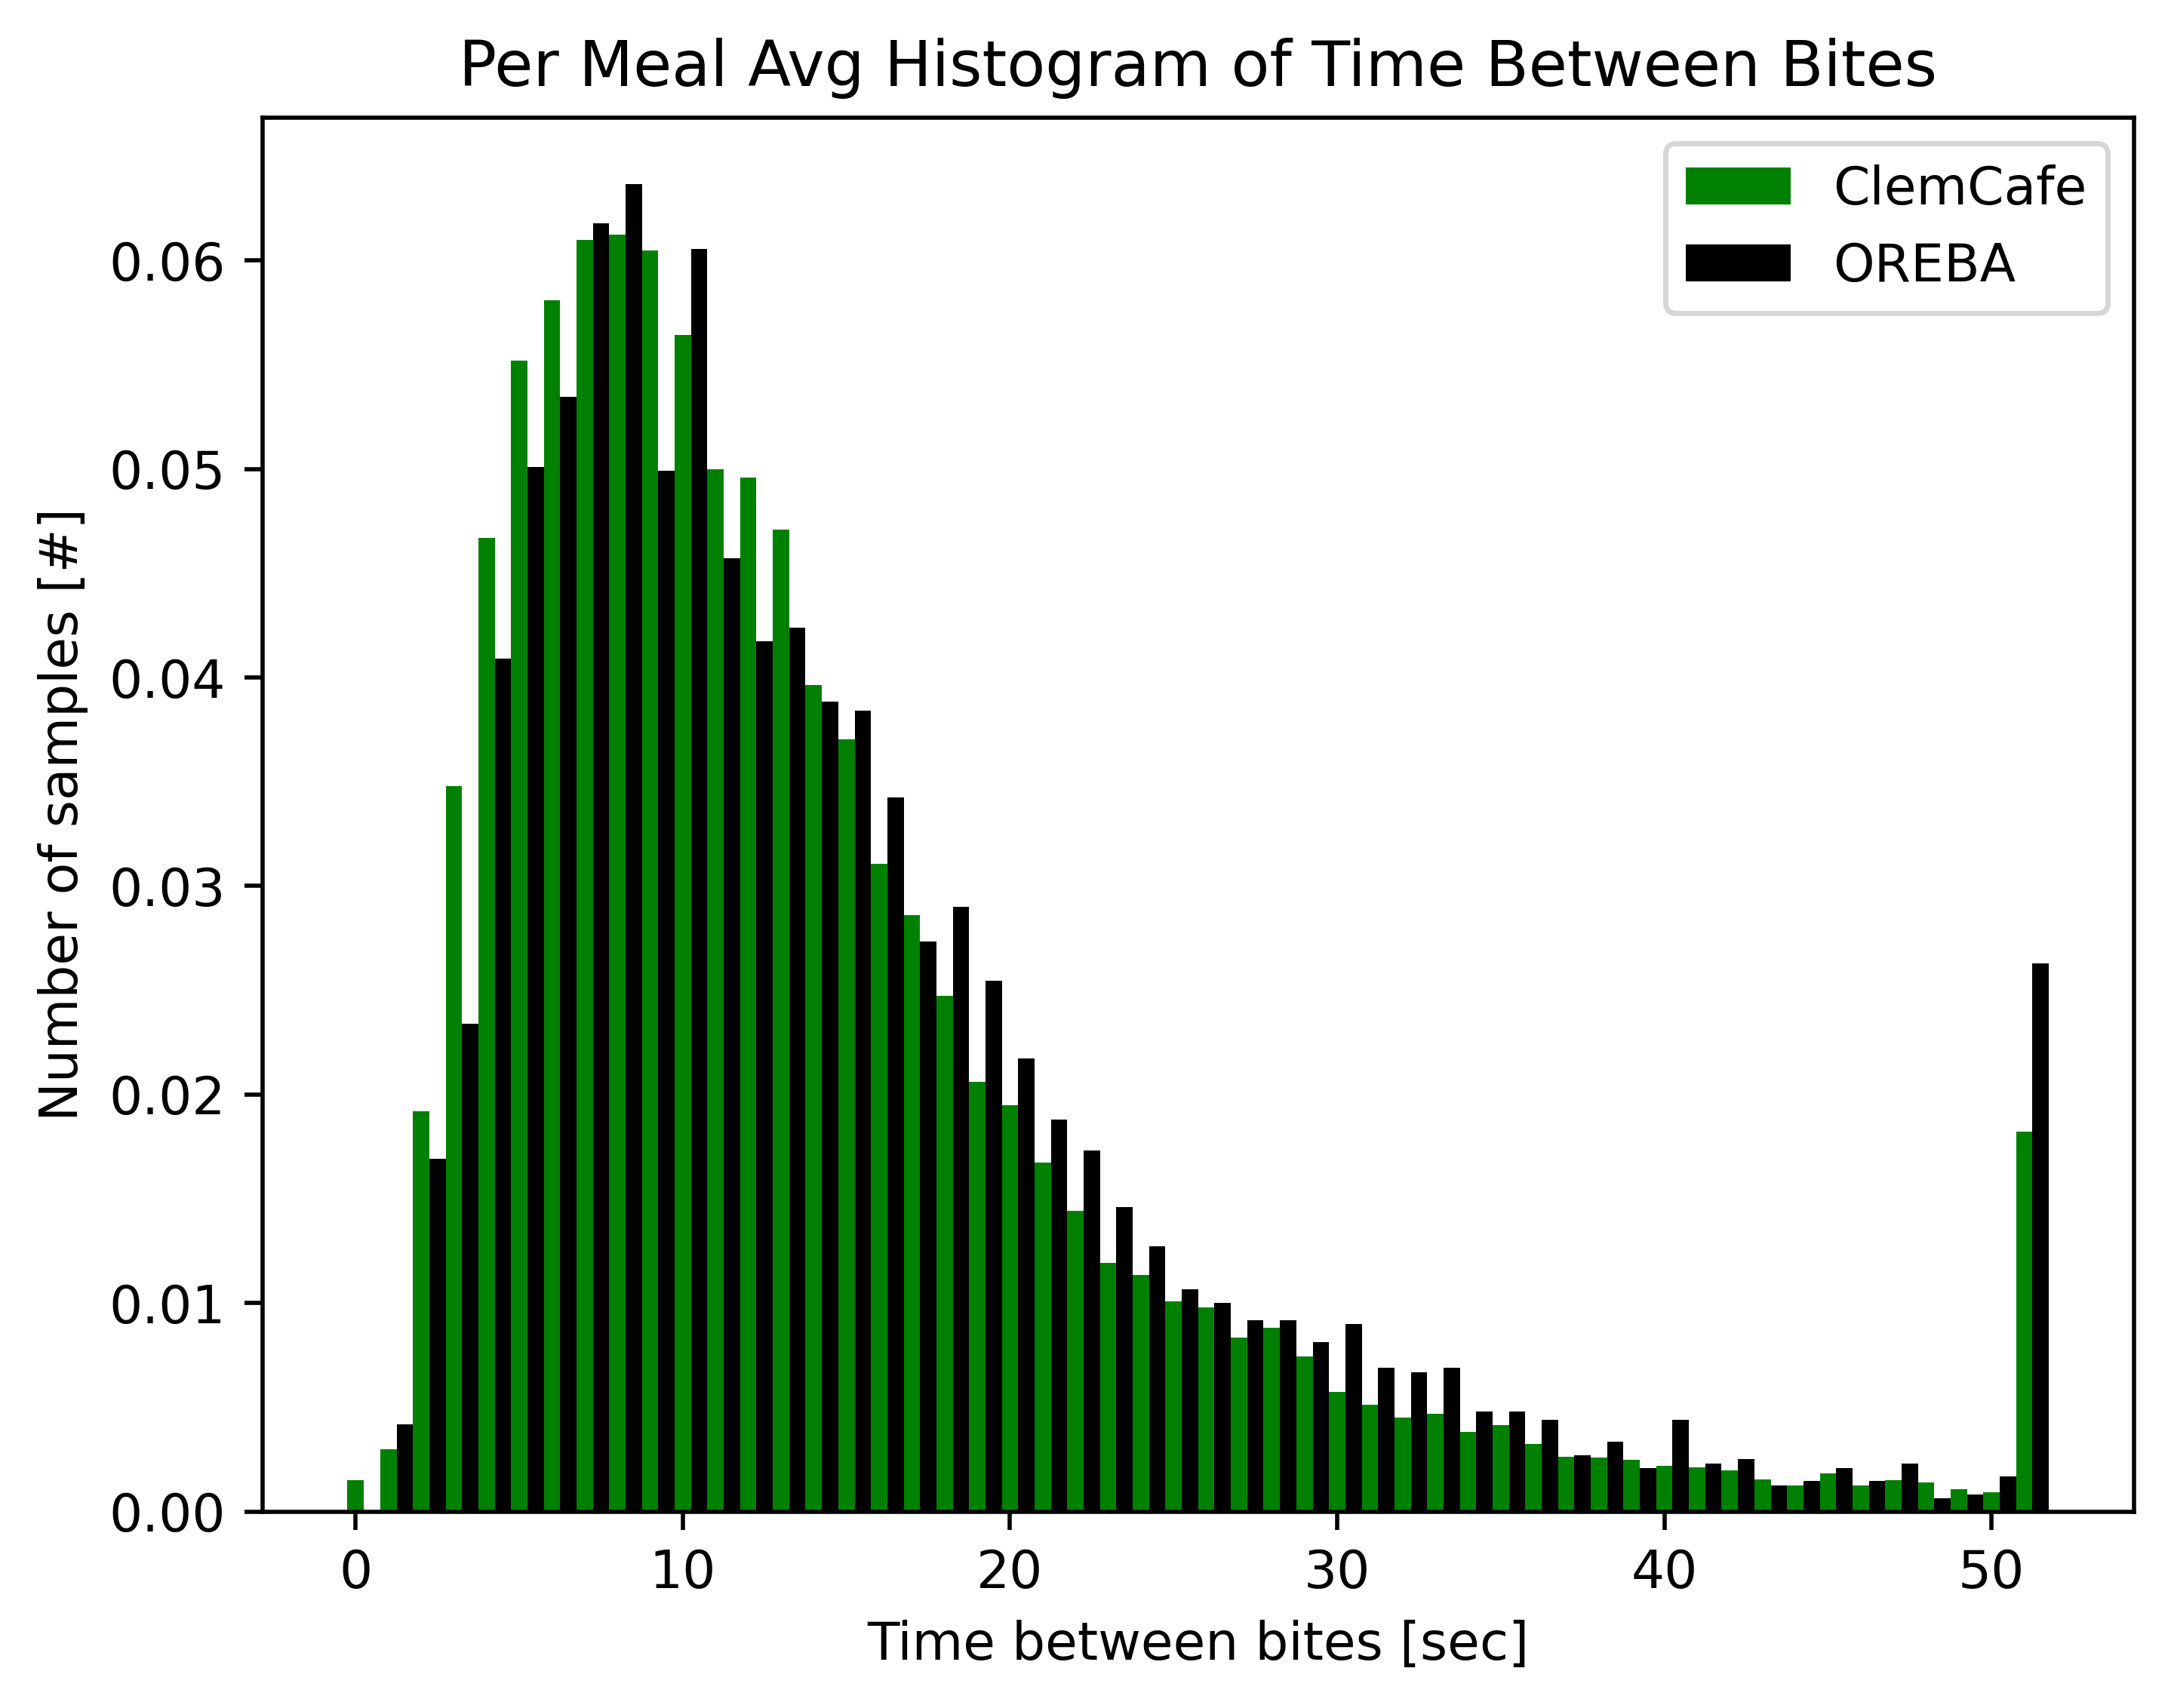

In [9]:
PLOT_CLEMCAFE = 1
PLOT_OREBA    = 1
# PLOT_FIC      = 0

NORMALIZE_BITES_PER_MEAL = 1

if NORMALIZE_BITES_PER_MEAL == 1:
	ydata_CC = Histogram_CC/len(bitesIndices)/avg_ClemCafe
	ydata_OREBA = Histogram_OREBA/len(bitesTimes2)/avg_OREBA
	# ydata_FIC = Histogram_FIC/len(bitesTimes3)/avg_FIC
else:
	ydata_CC = Histogram_CC/len(bitesIndices)
	ydata_OREBA = Histogram_OREBA/len(bitesTimes2)
	# ydata_FIC = Histogram_FIC/len(bitesTimes3)
	
	

totalPlots = PLOT_CLEMCAFE + PLOT_OREBA + PLOT_FIC
width = 1/totalPlots
PlotsDone = 0

indices = np.arange(0,MAX_SBB+1)

plt.figure("w",dpi=500)

legendEntries=[]
if PLOT_CLEMCAFE == 1:
	plt.bar(indices, ydata_CC, width=width, 
			color='g', label='ClemCafe')
	legendEntries.append("ClemCafe")
	PlotsDone+=1
if PLOT_OREBA == 1:
	plt.bar([i+PlotsDone*width for i in indices], ydata_OREBA, 
			width=width, color='k', alpha=1.0, label='OREBA')
	legendEntries.append("OREBA")
	PlotsDone+=1

if PLOT_FIC == 1:
	plt.bar([i+PlotsDone*width for i in indices], ydata_FIC, 
			width=width, color='b', alpha=0.9, label='FIC')
	legendEntries.append("FIC")
	PlotsDone+=1

plt.legend(legendEntries)

plt.title("Per Meal Avg Histogram of Time Between Bites")
plt.xlabel('Time between bites [sec]')
plt.ylabel('Number of samples [#]')

# plt.savefig("Histogram_SBB_PerMeal_OREBAvsCC.png")

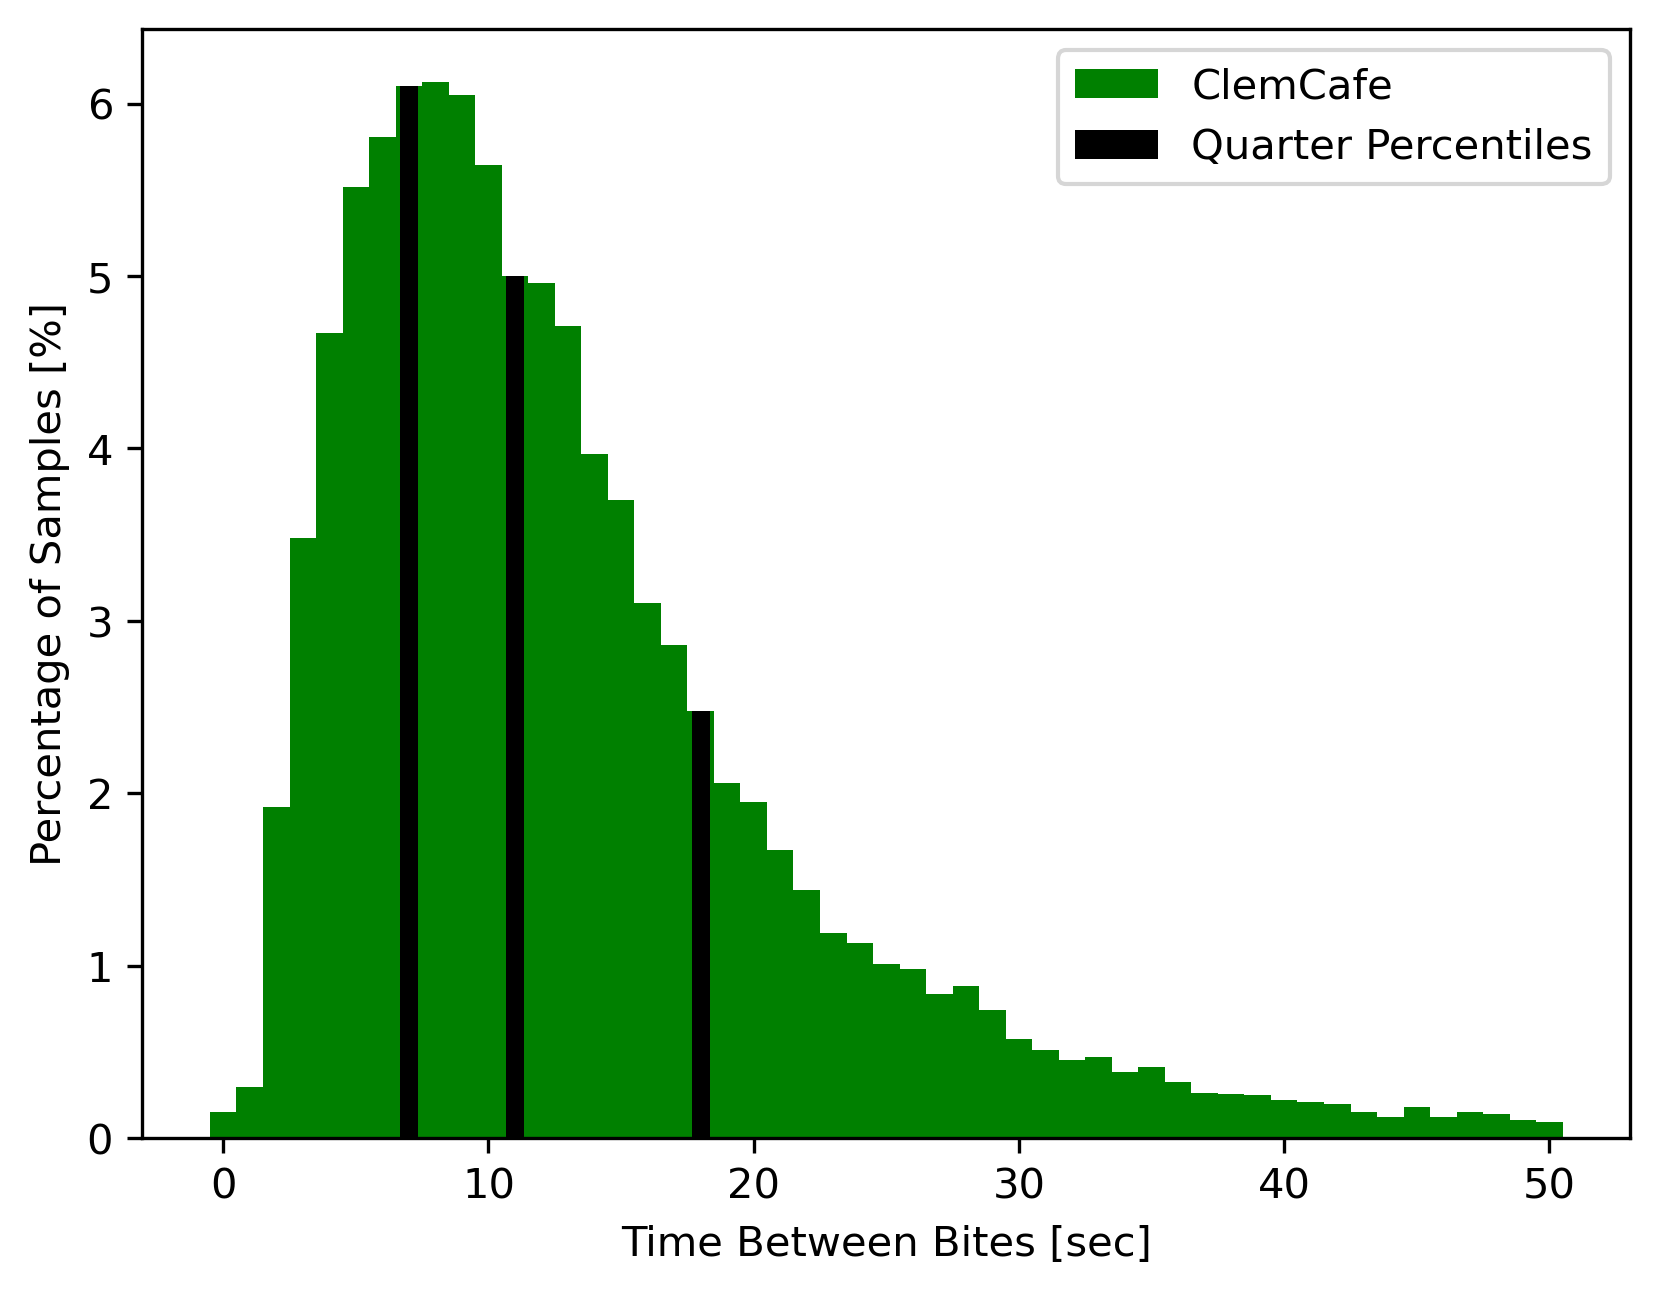

In [13]:
PLOT_CLEMCAFE = 1
PLOT_OREBA    = 0
PLOT_FIC      = 0

NORMALIZE_BITES_PER_MEAL = 1

if NORMALIZE_BITES_PER_MEAL == 1:
	ydata_CC = Histogram_CC[:MAX_SBB]/len(bitesIndices)/avg_ClemCafe
	ydata_OREBA = Histogram_OREBA[:MAX_SBB]/len(bitesTimes2)/avg_OREBA
	# ydata_FIC = Histogram_FIC[:MAX_SBB]/len(bitesTimes3)/avg_FIC
else:
	ydata_CC = Histogram_CC/len(bitesIndices)
	ydata_OREBA = Histogram_OREBA/len(bitesTimes2)
	# ydata_FIC = Histogram_FIC/len(bitesTimes3)
	
	

totalPlots = PLOT_CLEMCAFE + PLOT_OREBA + PLOT_FIC
width = 1/totalPlots
PlotsDone = 0

indices = np.arange(0,MAX_SBB)

plt.figure("w",dpi=300)

legendEntries=[]
if PLOT_CLEMCAFE == 1:
	plt.bar(indices, 100*ydata_CC, width=width, 
			color='g', label='ClemCafe')
	legendEntries.append("ClemCafe")
	PlotsDone+=1
if PLOT_OREBA == 1:
	plt.bar([i+PlotsDone*width for i in indices], ydata_OREBA, 
			width=width, color='k', alpha=1.0, label='OREBA')
	legendEntries.append("OREBA")
	PlotsDone+=1

if PLOT_FIC == 1:
	plt.bar([i+PlotsDone*width for i in indices], ydata_FIC, 
			width=width, color='b', alpha=0.9, label='FIC')
	legendEntries.append("FIC")
	PlotsDone+=1

	
#ADD PERCENTILE BARS
if True:
	plt.bar([7,11,18], 100*np.array([ydata_CC[7],ydata_CC[11],ydata_CC[18]]), width=width/1.5, 
			color='k', label='Percentiles')
	legendEntries.append("Quarter Percentiles")
	
# END ADD PERCENTILE BARS

plt.legend(legendEntries)

# plt.title("Per Meal Avg Histogram of Time Between Bites")
plt.xlabel('Time Between Bites [sec]')
plt.ylabel('Percentage of Samples [%]')

plt.savefig("Figures/Histogram_SBB_PerMeal_CC_Percentiles_TrimmedTail.pdf", bbox_inches='tight')

In [10]:
running_sum = 0
for i in range(len(ydata_CC)):
	running_sum += ydata_CC[i]
	print("{:2d} {}".format(i, running_sum))
#end for i

 0 0.0014947062487025119
 1 0.004484118746107536
 2 0.023666182271123104
 3 0.058459622171476024
 4 0.10516919244342952
 5 0.16034876479136392
 6 0.2184347104006643
 7 0.2794270292713307
 8 0.3406684658501142
 9 0.4011625493045464
10 0.45758771019306627
11 0.5075773302885613
12 0.5571517542038613
13 0.6042350010379904
14 0.6438862362466266
15 0.6809217355200332
16 0.7119784097986298
17 0.7405854266140751
18 0.7653311189537055
19 0.7859248494913846
20 0.8053975503425368
21 0.822129956404401
22 0.8365372638571724
23 0.848453394228773
24 0.8597882499481003
25 0.8698775171268422
26 0.8796761469794476
27 0.88802159020137
28 0.896823749221507
29 0.904255760847
30 0.909985468133693
31 0.9150923811500932
32 0.9196180195142202
33 0.9243097363504252
34 0.9281295412082206
35 0.932281503010172
36 0.9355200332156941
37 0.9381357691509234
38 0.9407099854681333
39 0.9432011625493042
40 0.9454017023043384
41 0.9475192028233336
42 0.9495121444882703
43 0.9510483703549922
44 0.9522939588955777
45 0.9541

In [ ]:
print(sum(Histogram_CC))
print(sum(Histogram_OREBA))

print(len(bitesIndices))
print(len(bitesTimes2))

In [ ]:
meal_times=dataset2['data_times']
print(meal_times[4][1])
print(1/64)

In [ ]:
### INVESTIGATION INTO HANDEDNESS AND BITES ###

In [5]:
# GenerateEvalData_OREBA()
DATABASE_FILEPATH = "./../Pickle_Databases/ClemCafe.pkl"


with open(DATABASE_FILEPATH,'rb') as fh:
	dataset = pkl.load(fh)
# ClemCafe_Cucumber={README,UniqueID,proc_data_rawAcc,proc_data_noG,handedness, ...
#             ... bites_gt, bites_handedness_gt, means_global_rawAcc, ...
#             ... stddev_global_rawAcc, means_global_noG, stddev_global_noG}


DomHands=dataset['handedness']
biteHands=dataset['bites_handedness_gt']

L_DomBites = 0
L_NonDBites = 0
L_BothBites = 0
R_DomBites = 0
R_NonDBites = 0
R_BothBites = 0

Righties=0
Lefties=0

for i in range(len(DomHands)):
	if DomHands[i]==0: # if right handed
		Righties+=1
		for j in range(len(biteHands[i])):
			if biteHands[i][j]=='right':
				R_DomBites+=1
			elif biteHands[i][j]=='both':
				R_BothBites+=1
			elif biteHands[i][j]=='left':
				R_NonDBites+=1
	else: # if DomHand==1 and is lefty
		Lefties+=1
		for j in range(len(biteHands[i])):
			if biteHands[i][j]=='left':
				L_DomBites+=1
			elif biteHands[i][j]=='both':
				L_BothBites+=1
			elif biteHands[i][j]=='right':
				L_NonDBites+=1
	
#end of for i ()

print("Righty Participants = {}".format(Righties))
print("Lefty  Participants = {}".format(Lefties))

print("{0:12s} | {1:5s} | {2:5s} | {3:5s} | {4:10s}".format("DomHand","Dom","Both","NonD","D-inv:NonD"))
print("{0:12s} | {1:5d} | {2:5d} | {3:5d} | {4:10.2f}".format(
	"RightHand", R_DomBites,R_BothBites,R_NonDBites,float(R_DomBites+R_BothBites)/R_NonDBites))
print("{0:12s} | {1:5d} | {2:5d} | {3:5d} | {4:10.2f}".format(
	"LeftHand", L_DomBites,L_BothBites,L_NonDBites,float(L_DomBites+L_BothBites)/L_NonDBites))

Righty Participants = 471
Lefty  Participants = 47
DomHand      | Dom   | Both  | NonD  | D-inv:NonD
RightHand    | 18281 |  1233 |  2529 |       7.72
LeftHand     |  1363 |   162 |   427 |       3.57


In [8]:
# GenerateEvalData_OREBA()
DATABASE_FILEPATH = "./../Pickle_Databases/OREBA.pkl"


with open(DATABASE_FILEPATH,'rb') as fh:
	dataset = pkl.load(fh)
# ClemCafe_Cucumber={README,UniqueID,proc_data_rawAcc,proc_data_noG,handedness, ...
#             ... bites_gt, bites_handedness_gt, means_global_rawAcc, ...
#             ... stddev_global_rawAcc, means_global_noG, stddev_global_noG}


DomHands=dataset['handedness']
biteHands=dataset['bites_handedness_gt']

L_DomBites = 0
L_NonDBites = 0
L_BothBites = 0
R_DomBites = 0
R_NonDBites = 0
R_BothBites = 0


Righties=0
Lefties=0



for i in range(len(DomHands)):
	if DomHands[i]=="right": # if right handed
		Righties+=1
		for j in range(len(biteHands[i])):
			if biteHands[i][j]==0:
				R_DomBites+=1
			elif biteHands[i][j]==2:
				R_BothBites+=1
			elif biteHands[i][j]==1:
				R_NonDBites+=1
	else: # if DomHand==1 and is lefty
		Lefties+=1
		for j in range(len(biteHands[i])):
			if biteHands[i][j]==1:
				L_DomBites+=1
			elif biteHands[i][j]==2:
				L_BothBites+=1
			elif biteHands[i][j]==0:
				L_NonDBites+=1
	
#end of for i ()
print("Righty Participants = {}".format(Righties))
print("Lefty  Participants = {}".format(Lefties))

print("{0:12s} | {1:5s} | {2:5s} | {3:5s} | {4:10s}".format("DomHand","Dom","Both","NonD","D-inv:NonD"))
print("{0:12s} | {1:5d} | {2:5d} | {3:5d} | {4:10.2f}".format(
	"RightHand", R_DomBites,R_BothBites,R_NonDBites,float(R_DomBites+R_BothBites)/R_NonDBites))
print("{0:12s} | {1:5d} | {2:5d} | {3:5d} | {4:10.2f}".format(
	"LeftHand", L_DomBites,L_BothBites,L_NonDBites,float(L_DomBites+L_BothBites)/L_NonDBites))

Righty Participants = 88
Lefty  Participants = 12
DomHand      | Dom   | Both  | NonD  | D-inv:NonD
RightHand    |  2818 |   114 |  1207 |       2.43
LeftHand     |   493 |    16 |   142 |       3.58
